## 1. Import thư viện, tạo dữ liệu giả (dummy data) và hiển thị dữ liệu

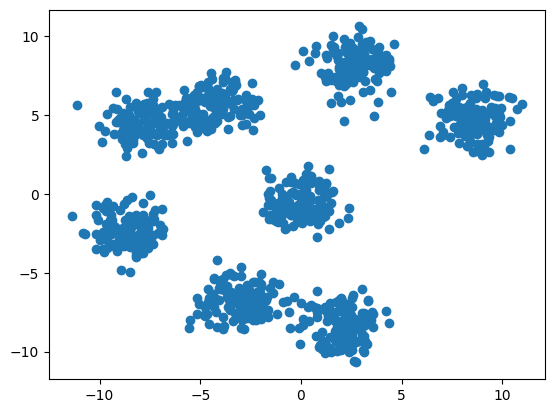

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline
# Generate a random cluster dataset to experiment on. X = coordinate points, y = cluster labels (not needed)

X, y = make_blobs(n_samples=1000, centers=8, n_features=2,
random_state=800)
plt.scatter(X[:,0], X[:,1])
plt.savefig("../results/models/clustering.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Hiển thị ma trận khoảng cách giữa các điểm dữ liệu với điểm trung tâm

In [3]:
# Generate distance matrix with 'linkage' function
distances = linkage(X, method="centroid", metric="euclidean")
print(distances)

[[5.72000000e+02 7.62000000e+02 7.69412624e-03 2.00000000e+00]
 [3.00000000e+01 1.96000000e+02 8.87881891e-03 2.00000000e+00]
 [5.91000000e+02 8.70000000e+02 1.07476240e-02 2.00000000e+00]
 ...
 [1.98900000e+03 1.99200000e+03 7.81168528e+00 3.75000000e+02]
 [1.99500000e+03 1.99600000e+03 1.02408477e+01 7.50000000e+02]
 [1.99400000e+03 1.99700000e+03 1.20025814e+01 1.00000000e+03]]


## 3. Vẽ hình dendrogram từ ma trận khoảng cách

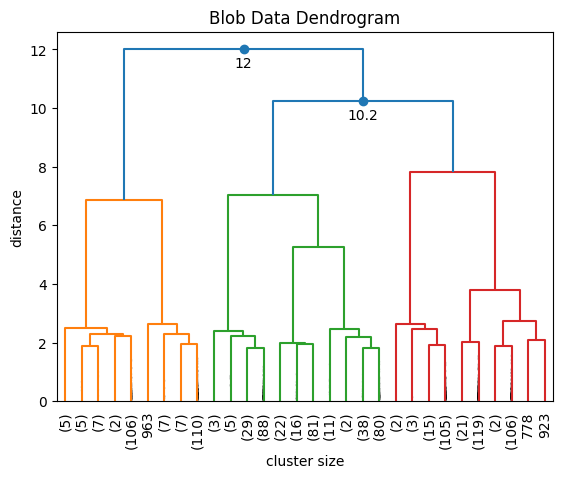

In [4]:
# Take normal dendrogram output and stylize in cleaner way
def annotated_dendrogram(*args, **kwargs):
# Standard dendrogram from SciPy
    scipy_dendro = dendrogram(*args, truncate_mode='lastp',
    show_contracted=True,leaf_rotation=90.)
    plt.title('Blob Data Dendrogram')
    plt.xlabel('cluster size')
    plt.ylabel('distance')
    for i, d, c in zip(scipy_dendro['icoord'], scipy_dendro['dcoord'],
    scipy_dendro['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        if y > 10:
            plt.plot(x, y, 'o', c=c)
            plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
    textcoords='offset points',
    va='top', ha='center')

    return scipy_dendro
dn = annotated_dendrogram(distances)
plt.show()

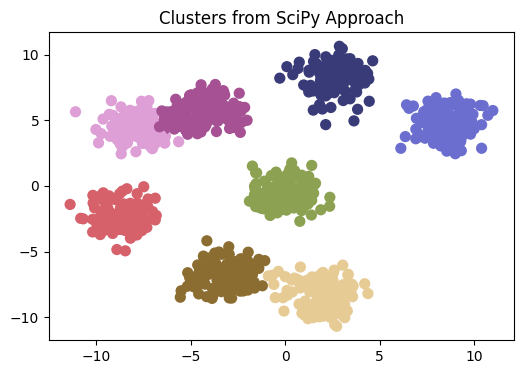

In [5]:
scipy_clusters = fcluster(distances, 3, criterion="distance")
plt.figure(figsize=(6,4))
plt.title("Clusters from SciPy Approach")
plt.scatter(X[:, 0], X[:, 1], c = scipy_clusters ,s=50, cmap='tab20b')
plt.show()

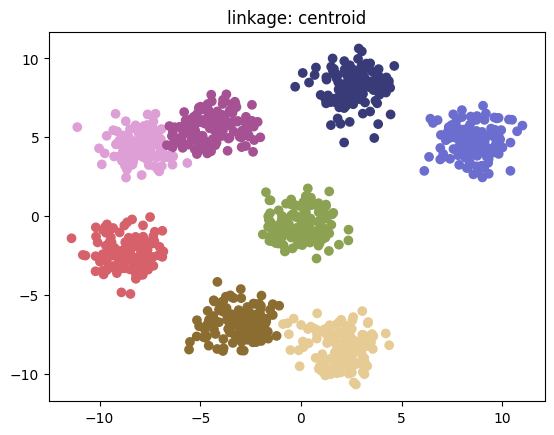

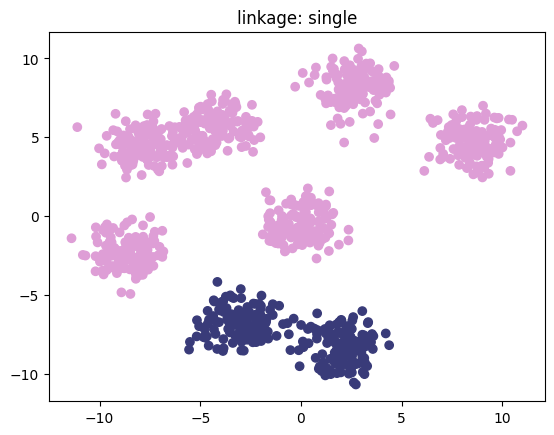

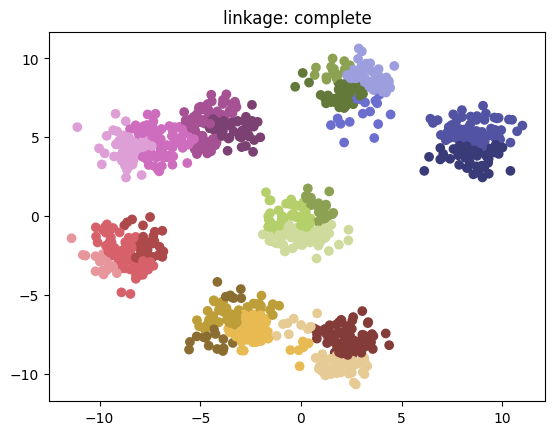

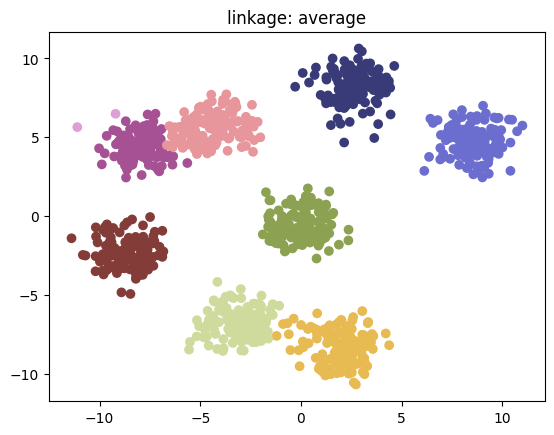

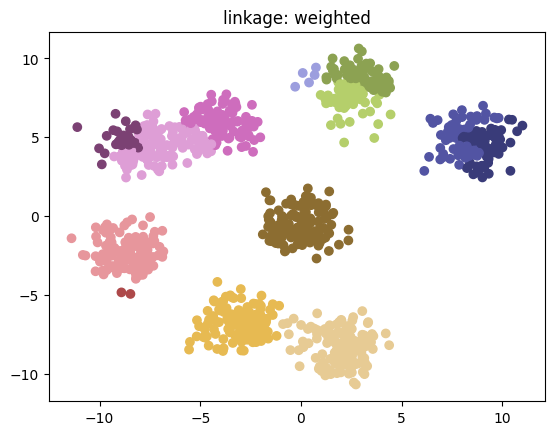

In [6]:

methods = ['centroid', 'single', 'complete', 'average', 'weighted']
for method in methods:
    distances = linkage(X, method=method, metric="euclidean")
    clusters = fcluster(distances, 3, criterion="distance")
    plt.title('linkage: ' + method)
    plt.scatter(X[:,0], X[:,1], c=clusters, cmap='tab20b')
    plt.show()  

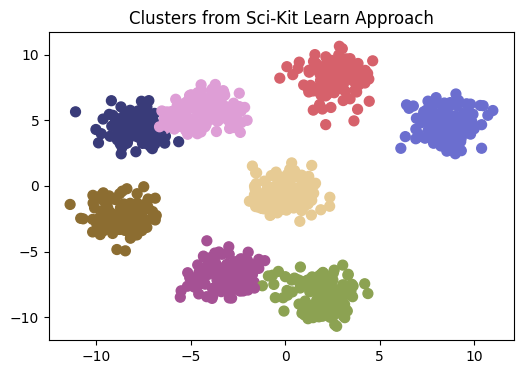

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

ac = AgglomerativeClustering(n_clusters = 8, linkage="average")
#distances = linkage(X, method="centroid", metric="euclidean")
sklearn_clusters = ac.fit_predict(X)
scipy_clusters = fcluster(distances, 3, criterion="distance")
plt.figure(figsize=(6,4))
plt.title("Clusters from Sci-Kit Learn Approach")
plt.scatter(X[:, 0], X[:, 1], c = sklearn_clusters ,s=50, cmap='tab20b')
plt.show()